# Homework 1 — Section 4: Decision Trees

## Step 1: Read the data with pandas

Each TSV file has a header row. The last column contains the class label, and the other columns contain the features (Section 4.1 of the handout).

Run this notebook from its `Programming` folder. The supplied validation files use `_val.tsv` in their names.

This readable edition follows the same sections and cell order as `decision_tree.ipynb`. Run the cells from top to bottom. Functions are defined first and used in the examples and experiments that follow.

A **DataFrame** is a table; a **Series** is one column. In this notebook, every dataset keeps its label in the last column. `data.iloc[:, -1]` means “all rows, last column”; `data.iloc[:, :-1]` means “all rows, every column except the last.” Negative positions count backward from the end.

We use **training data** to choose splits and leaf predictions. We use **validation data** to measure accuracy and, in Question 3, decide which branches to prune. The short suffix `val` always means validation.


In [1]:
import pandas as pd

# A TSV file uses tabs to separate columns. Pandas reads its first row as names.
# Keep each training set separate from the validation set used to evaluate it.
small_train = pd.read_csv("small_train.tsv", sep="\t")
small_val = pd.read_csv("small_val.tsv", sep="\t")

heart_train = pd.read_csv("heart_train.tsv", sep="\t")
heart_val = pd.read_csv("heart_val.tsv", sep="\t")

education_train = pd.read_csv("education_train.tsv", sep="\t")
education_val = pd.read_csv("education_val.tsv", sep="\t")


### Inspect the small dataset

`head()` displays the first five rows, including the column names. Here, `chest_pain` and `thalassemia` are features; `heart_disease` is the label we will predict.


In [2]:
small_train.head()


,chest_pain,thalassemia,heart_disease
0,0,1,1
1,1,0,0
2,0,0,1
3,0,0,1
4,1,0,0


### Check dataset sizes

Each DataFrame's `shape` gives `(number of rows, number of columns)`. The column count includes the label.


In [3]:
# Each shape is (number of examples, number of columns including the label).
print("Small — training:", small_train.shape, "validation:", small_val.shape)
print("Heart — training:", heart_train.shape, "validation:", heart_val.shape)
print("Education — training:", education_train.shape, "validation:", education_val.shape)


Small — training: (28, 3) validation: (28, 3)
Heart — training: (200, 9) validation: (97, 9)
Education — training: (200, 11) validation: (200, 11)


## Step 2: Calculate entropy

Entropy measures how mixed the labels are at a node (Section 4.2.1 of the handout).

$$H(Y) = -\sum_y p(y)\log_2 p(y)$$

For binary labels, entropy is **0 bits** when every label is the same and **1 bit** when the labels are evenly split.

`value_counts(normalize=True)` gives the proportion of each observed label. We use those proportions in the formula. Since only observed labels are included, we never take the logarithm of zero. For an empty group, we return 0 so it contributes nothing when we later calculate a split's weighted entropy.

Read the loop as: find each label’s proportion, calculate its contribution, and add that contribution to the total. `log2` gives entropy in bits. For an even split, each label contributes 0.5 bits, totaling 1 bit.


In [4]:
from math import log2


def entropy(labels):
    """Measure uncertainty in a pandas Series of binary labels, in bits."""
    # An empty branch contributes no uncertainty to a weighted split.
    if labels.empty:
        return 0.0

    # Example: [0, 1, 1, 1] gives proportions 0.25 for 0 and 0.75 for 1.
    label_probabilities = labels.value_counts(normalize=True)

    total_entropy = 0.0
    for probability in label_probabilities:
        # Only observed labels are counted, so probability is never zero.
        label_contribution = -probability * log2(probability)
        total_entropy = total_entropy + label_contribution

    return total_entropy


### Try a few examples

The small training dataset has 14 zeros and 14 ones, so its label entropy should be 1 bit. `iloc[:, -1]` selects the last column, which contains the labels.


In [5]:
identical_labels = pd.Series([1, 1, 1, 1])
balanced_labels = pd.Series([0, 0, 1, 1])
mostly_one_labels = pd.Series([0, 1, 1, 1])
small_training_labels = small_train.iloc[:, -1]

print("All labels the same:", entropy(identical_labels))
print("Evenly split labels:", entropy(balanced_labels))
print("Mostly one label:", entropy(mostly_one_labels))
print("Small training labels:", entropy(small_training_labels))


All labels the same: 0.0
Evenly split labels: 1.0
Mostly one label: 0.8112781244591328
Small training labels: 1.0


Next, we will use entropy to calculate **mutual information**: how much a feature split reduces label uncertainty.


## Step 3: Calculate mutual information

Mutual information (also called information gain here) measures how much splitting on a feature reduces label uncertainty. Section 4.2 requires this weighted calculation:

$$I(Y;X) = H(Y) - P(X=0)H(Y\mid X=0) - P(X=1)H(Y\mid X=1)$$

We split the DataFrame into two groups using the feature's value. Each group's weight is its fraction of the total rows, so larger groups contribute more to the remaining uncertainty. Subtracting that weighted entropy from the original entropy gives the information gain.


In [6]:
def mutual_information(data, feature):
    """Return the reduction in label entropy from splitting on one feature."""
    if data.empty:
        return 0.0

    # 1. Measure uncertainty before splitting. The final column is the label.
    all_labels = data.iloc[:, -1]
    entropy_before_split = entropy(all_labels)

    # 2. Separate the rows according to this feature's value.
    feature_values = data[feature]
    rows_with_zero = data[feature_values == 0]
    rows_with_one = data[feature_values == 1]

    # 3. Measure uncertainty within each group.
    zero_group_labels = rows_with_zero.iloc[:, -1]
    one_group_labels = rows_with_one.iloc[:, -1]
    zero_group_entropy = entropy(zero_group_labels)
    one_group_entropy = entropy(one_group_labels)

    # 4. Weight each group's entropy by its share of the original rows.
    total_rows = len(data)
    zero_group_weight = len(rows_with_zero) / total_rows
    one_group_weight = len(rows_with_one) / total_rows
    entropy_after_split = (
        zero_group_weight * zero_group_entropy
        + one_group_weight * one_group_entropy
    )

    information_gain = entropy_before_split - entropy_after_split
    return information_gain


### Compare the small dataset's features

`columns[:-1]` selects all feature names, excluding the label column. A larger gain means the split removes more uncertainty. We use the training data to evaluate splits.


In [7]:
# Exclude the last column: it is the answer, not a candidate feature.
feature_names = small_train.columns[:-1]

for feature_name in feature_names:
    information_gain = mutual_information(small_train, feature_name)
    print(f"{feature_name}: {information_gain:.6f} bits")


chest_pain: 0.257831 bits
thalassemia: 0.136879 bits


`chest_pain` has the larger information gain, so it is the preferred root split. This agrees with the small-tree example in Section 4.2.2.

Next, we will choose the best feature automatically. The handout requires choosing the first column when gains tie and only splitting when the best gain is greater than the threshold (0 by default).


## Step 4: Choose the best feature

We compare the information gain of each feature in column order. Section 4.2 gives two rules:

- Only split if the information gain is **greater than** the threshold (0 by default).
- If multiple features have the same gain, choose the **first column**.

Starting `best_gain` at the threshold ensures that a feature must beat it to be selected. Updating only when `information_gain > best_gain` keeps the earlier feature when gains tie. If no feature qualifies, we return `None`, meaning this node should become a leaf.


In [8]:
def best_feature(data, threshold=0.0):
    """Return a feature name, or None when no split beats the threshold."""
    chosen_feature = None
    best_gain = threshold
    feature_names = data.columns[:-1]

    # Original column order matters because the first feature wins a tie.
    for feature_name in feature_names:
        information_gain = mutual_information(data, feature_name)

        # Strictly greater: equal gains never replace the earlier choice.
        if information_gain > best_gain:
            chosen_feature = feature_name
            best_gain = information_gain

    return chosen_feature


### Try it on the small dataset

At the default threshold, we should choose `chest_pain`. At a threshold of 0.30 bits, neither feature qualifies because both gains are below 0.30.


In [9]:
default_choice = best_feature(small_train)
higher_threshold_choice = best_feature(small_train, threshold=0.30)

print("Default threshold:", default_choice)
print("Threshold of 0.30:", higher_threshold_choice)


Default threshold: chest_pain
Threshold of 0.30: None


Next, we will define how a leaf predicts its label using majority vote, including the required rule that a tie predicts 1.


## Step 5: Predict with majority vote

A leaf predicts the most common training label among the examples that reach it. Section 4.2 requires choosing **1 when the counts tie**.

For a pandas Series, `labels == 0` marks each zero as `True`. Summing those values counts the zeros; the same approach counts the ones. Using `>=` makes a tie choose 1.


In [10]:
def majority_vote(labels):
    """Return the most common binary label; a tie returns 1."""
    # Summing a True/False Series counts its True entries.
    is_label_zero = labels == 0
    is_label_one = labels == 1
    count_0 = is_label_zero.sum()
    count_1 = is_label_one.sum()

    # Include equality to implement the assignment's tie rule.
    if count_1 >= count_0:
        return 1
    return 0


### Try a few examples

The small training dataset has 14 zeros and 14 ones, so its majority vote is 1. A tree with maximum depth 0 would make this same prediction for every example because it never splits.


In [11]:
mostly_zero_labels = pd.Series([0, 0, 0, 1])
mostly_one_labels = pd.Series([0, 1, 1, 1])
tied_labels = pd.Series([0, 0, 1, 1])
small_training_labels = small_train.iloc[:, -1]

print("Mostly zeros:", majority_vote(mostly_zero_labels))
print("Mostly ones:", majority_vote(mostly_one_labels))
print("Tied labels:", majority_vote(tied_labels))
print("Small training labels:", majority_vote(small_training_labels))


Mostly zeros: 0
Mostly ones: 1
Tied labels: 1
Small training labels: 1


Next, we will define a tree node to store its prediction, label counts, split feature, and children.


## Step 6: Define a tree node

Section 4.2.1 suggests representing the tree as a collection of nodes. Each node holds information about the training examples that reach it:

- `count_0` and `count_1`: label counts, which we will use when printing the tree.
- `prediction`: the majority label, which the node predicts if it is a leaf.
- `feature`: the feature used to split, or `None` for a leaf.
- `left` and `right`: child nodes for feature values 0 and 1, respectively.

Every node starts as a leaf. When we build the tree, we can give it a split feature and two children. We keep the majority prediction even at internal nodes so we can later turn a subtree into a leaf during pruning.

`__init__` runs when we create a node, and `self` refers to that particular node.


In [12]:
class Node:
    """Store one node's training counts, prediction, and optional split."""

    def __init__(self, labels):
        # These counts describe only the training examples reaching this node.
        self.count_0 = int((labels == 0).sum())
        self.count_1 = int((labels == 1).sum())

        # Keep this prediction even if the node later becomes a split.
        # Pruning can turn it back into a leaf without relearning its label.
        self.prediction = majority_vote(labels)

        # None means this node is currently a leaf, with no children.
        self.feature = None
        self.left = None    # Child for feature value 0.
        self.right = None   # Child for feature value 1.


### Create a root node

The root receives all training examples. For the small dataset, its counts should be 14 zeros and 14 ones, and its prediction should be 1. This example only creates the node; it does not split the data yet.


In [13]:
small_training_labels = small_train.iloc[:, -1]
root = Node(small_training_labels)

print(f"Label counts: [{root.count_0} 0/{root.count_1} 1]")
print("Prediction:", root.prediction)
print("Split feature:", root.feature)
print("Children:", root.left, root.right)


Label counts: [14 0/14 1]
Prediction: 1
Split feature: None
Children: None None


Next, we will build the tree recursively: create a node, check the stopping rules, choose a feature, and repeat for its two groups.


## Step 7: Build the tree recursively

Each call builds one node from the training rows that reach it. We start by creating a leaf with a majority prediction, then stop if:

- The node has reached the maximum depth. The root is at depth 0.
- The node has fewer training rows than `min_size` (used in Question 5; the default 0 imposes no size restriction).
- All labels at the node are the same.
- No feature has information gain greater than the threshold.

Otherwise, we choose the best feature and split the rows into groups for values 0 and 1. We call the same function on each group to build the left and right children. This is **recursion**: each smaller group is handled using the same steps.

`max_depth=None` means no depth limit. After splitting, we drop the chosen feature from each group because it is constant within that branch. The remaining columns stay in their original order, and the label stays last. When no features remain, `best_feature()` returns `None`.

For example, the root receives 28 small training rows. Splitting on `chest_pain` sends 16 rows to the left call and 12 to the right call. Each call creates its own node. The returned nodes become the root’s children. A `return node` at a stopping rule finishes only that branch.


In [14]:
def build_tree(data, max_depth=None, threshold=0.0, depth=0, min_size=0):
    """Build a subtree from the nonempty training rows reaching this node.

    max_depth: deepest allowed level; None means unlimited.
    threshold: information gain must exceed this value to allow a split.
    depth: this node's level; the initial call starts at 0.
    min_size: a node needs at least this many rows before it may split.
    """
    # 1. Start with a leaf. Any stopping rule below can return it as-is.
    labels = data.iloc[:, -1]
    node = Node(labels)

    # 2. Check whether we must stop growing this branch.
    if max_depth is not None:
        if depth >= max_depth:
            return node

    if len(data) < min_size:
        return node

    number_of_distinct_labels = labels.nunique()
    if number_of_distinct_labels == 1:
        return node

    split_feature = best_feature(data, threshold=threshold)
    if split_feature is None:
        return node

    # 3. Turn the leaf into a split and divide its training rows.
    node.feature = split_feature
    feature_values = data[split_feature]
    left_data = data[feature_values == 0]
    right_data = data[feature_values == 1]

    # This feature is constant within each child and cannot help there again.
    left_data = left_data.drop(columns=split_feature)
    right_data = right_data.drop(columns=split_feature)

    # 4. Each recursive call repeats these steps for one smaller group.
    # The limits stay the same; only the current depth increases.
    child_depth = depth + 1
    node.left = build_tree(
        data=left_data,
        max_depth=max_depth,
        threshold=threshold,
        depth=child_depth,
        min_size=min_size,
    )
    node.right = build_tree(
        data=right_data,
        max_depth=max_depth,
        threshold=threshold,
        depth=child_depth,
        min_size=min_size,
    )

    # Returning the node also returns access to every child attached to it.
    return node


### Build the small tree

With maximum depth 2, the root should split on `chest_pain`, and both children should split on `thalassemia`, matching Section 4.2.2. With maximum depth 0, the root stays a leaf and predicts 1.


In [15]:
small_tree = build_tree(small_train, max_depth=2)

print("Root split:", small_tree.feature)
print("Split where chest_pain = 0:", small_tree.left.feature)
print("Split where chest_pain = 1:", small_tree.right.feature)

depth_0_tree = build_tree(small_train, max_depth=0)
print("\nDepth-0 split:", depth_0_tree.feature)
print("Depth-0 prediction:", depth_0_tree.prediction)


Root split: chest_pain
Split where chest_pain = 0: thalassemia
Split where chest_pain = 1: thalassemia

Depth-0 split: None
Depth-0 prediction: 1


Next, we will print the full tree with indentation and label counts in the format required by Section 4.2.2.


## Step 8: Print the tree

Section 4.2.2 asks us to print each node before its children. This is a **pre-order depth-first traversal**: print the current node, then its left subtree, then its right subtree.

The root line contains only its label counts. Every other line shows the parent's split feature, the branch value that led to this node, and this node's label counts. We repeat `"| "` once per depth level to show the tree's structure.

For example, `| chest_pain = 0: [4 0/12 1]` means that the root's value-0 branch contains 4 label-0 examples and 12 label-1 examples. The feature printed on this line describes how we reached the node, rather than the node's own next split.


In [16]:
def print_tree(node, depth=0, parent_feature=None, branch_value=None):
    """Print this node, then its left subtree, then its right subtree."""
    label_counts = f"[{node.count_0} 0/{node.count_1} 1]"

    # The root has no incoming branch, so it prints only its counts.
    if parent_feature is None:
        print(label_counts)
    else:
        indentation = "| " * depth
        incoming_branch = f"{parent_feature} = {branch_value}"
        print(f"{indentation}{incoming_branch}: {label_counts}")

    # A leaf has no children to print.
    if node.feature is None:
        return

    child_depth = depth + 1
    print_tree(
        node=node.left,
        depth=child_depth,
        parent_feature=node.feature,
        branch_value=0,
    )
    print_tree(
        node=node.right,
        depth=child_depth,
        parent_feature=node.feature,
        branch_value=1,
    )


### Print the small tree

This depth-2 tree should match the small dataset example in Section 4.2.2. Printing happens after training is complete.


In [17]:
print_tree(small_tree)


[14 0/14 1]
| chest_pain = 0: [4 0/12 1]
| | thalassemia = 0: [3 0/4 1]
| | thalassemia = 1: [1 0/8 1]
| chest_pain = 1: [10 0/2 1]
| | thalassemia = 0: [7 0/0 1]
| | thalassemia = 1: [3 0/2 1]


A depth-0 tree is just one leaf, so its output contains only the root counts.


In [18]:
print_tree(depth_0_tree)


[14 0/14 1]


Next, we will use a trained tree to predict labels for new rows, then calculate training and validation error.


## Step 9: Predict labels and calculate error

To predict one row, start at the root and look up the row's value for the split feature. Follow the left child for 0 or the right child for 1. Repeat until reaching a leaf, then return its majority prediction.

Predictions use only the features. The true labels are used afterward to evaluate the predictions, as required by Section 4.2.


In [19]:
def predict_one(tree, row):
    """Follow one example's feature values from the root to a leaf."""
    current_node = tree

    # Continue until there is no split feature: that means we reached a leaf.
    while current_node.feature is not None:
        feature_name = current_node.feature
        feature_value = row[feature_name]

        if feature_value == 0:
            current_node = current_node.left
        else:
            current_node = current_node.right

    return current_node.prediction


def predict(tree, features):
    """Predict every row and keep the input DataFrame's row indexes."""
    predicted_labels = []

    # iterrows() gives the row index and the row's values as a Series.
    for row_index, row in features.iterrows():
        predicted_label = predict_one(tree, row)
        predicted_labels.append(predicted_label)

    # Matching indexes let pandas compare each prediction with its true label.
    predictions = pd.Series(predicted_labels, index=features.index, dtype=int)
    return predictions


### Measure mistakes

`predict()` loops through rows with `iterrows()`, collects one prediction per row, and returns a Series with the same indexes. Indexes identify which original row each prediction belongs to, even after filtering leaves gaps in the row numbers.

The error rate is `number of mistakes / number of examples`. Comparing the label and prediction Series gives `True` for each mistake. Summing those values counts the mistakes. The two Series must refer to the same rows with matching indexes. Accuracy is `1 - error`.

For example, 6 wrong predictions out of 28 give an error of about 0.2143 and an accuracy of about 0.7857. These evaluation examples all use nonempty datasets.


In [20]:
def error_rate(labels, predictions):
    """Return the fraction of wrong predictions for matching row indexes."""
    incorrect_predictions = labels != predictions
    number_of_mistakes = incorrect_predictions.sum()
    number_of_examples = len(labels)

    error = number_of_mistakes / number_of_examples
    return error


### Evaluate the small tree

`iloc[:, :-1]` selects the feature columns, while `iloc[:, -1]` selects the labels. We use the same trained tree for both datasets; validation rows do not change the tree.


In [21]:
# Separate the inputs from the answers before making predictions.
training_features = small_train.iloc[:, :-1]
training_labels = small_train.iloc[:, -1]
validation_features = small_val.iloc[:, :-1]
validation_labels = small_val.iloc[:, -1]

small_train_predictions = predict(small_tree, training_features)
small_val_predictions = predict(small_tree, validation_features)

train_error = error_rate(training_labels, small_train_predictions)
val_error = error_rate(validation_labels, small_val_predictions)
train_accuracy = 1 - train_error
val_accuracy = 1 - val_error

print(f"Training error: {train_error:.6f}")
print(f"Validation error: {val_error:.6f}")
print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Validation accuracy: {val_accuracy:.2%}")


Training error: 0.214286
Validation error: 0.285714
Training accuracy: 78.57%
Validation accuracy: 71.43%


Compare the first few validation predictions with their true labels:


In [22]:
validation_labels = small_val.iloc[:, -1]
prediction_comparison = pd.DataFrame({
    "Actual": validation_labels,
    "Predicted": small_val_predictions,
})
prediction_comparison.head()


,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0


The supplied `example_output/small_3_metrics.txt` reports the same errors (its `test` split corresponds to our validation split). Although that example uses maximum depth 3, the small dataset has only two features, so increasing the limit from 2 to 3 does not change this tree.

Next, we can answer Section 4.3, Question 1: report validation accuracy for all three datasets with no maximum depth limit and the default information gain threshold.


## Section 4.3 — Question 1: Validation accuracy

Train a separate decision tree on each dataset using **no maximum depth limit** and the default **information gain threshold of 0**. Then report its accuracy on the corresponding validation set.

`max_depth=None` removes the depth limit. The other stopping rules still apply: pure labels or no positive information gain stop a branch. Each tree learns from training rows only.


In [23]:
# Each tuple contains a name, its training data, and its validation data.
datasets = [
    ("small", small_train, small_val),
    ("heart", heart_train, heart_val),
    ("education", education_train, education_val),
]

results = []
for dataset_name, training_data, validation_data in datasets:
    tree = build_tree(training_data, max_depth=None, threshold=0.0)

    validation_features = validation_data.iloc[:, :-1]
    validation_labels = validation_data.iloc[:, -1]
    predictions = predict(tree, validation_features)
    validation_error = error_rate(validation_labels, predictions)
    validation_accuracy = 1 - validation_error

    dataset_result = {
        "Dataset": dataset_name,
        "Validation accuracy (%)": 100 * validation_accuracy,
    }
    results.append(dataset_result)

# Keep the original numeric results; round only the displayed table.
accuracy_results = pd.DataFrame(results)
accuracy_results.round(2)


,Dataset,Validation accuracy (%)
0,small,71.43
1,heart,74.23
2,education,100.00


### Answer

- **small**: 71.43%
- **heart**: 74.23%
- **education**: 100.00%

Next, Question 2 asks us to print the heart dataset tree with maximum depth 4.


## Section 4.3 — Question 2: Heart tree with maximum depth 4

Train on `heart_train` with `max_depth=4` and the default information gain threshold of 0. The root is at depth 0, so nodes at depth 4 must be leaves; some branches may stop earlier.

The printed tree below is the answer to Question 2. Each line shows training label counts, following the format in Section 4.2.2. We keep this tree as `heart_tree_depth4` for the pruning question next.


In [24]:
heart_tree_depth4 = build_tree(heart_train, max_depth=4, threshold=0.0)
print_tree(heart_tree_depth4)


[102 0/98 1]
| thalassemia = 0: [81 0/22 1]
| | chest_pain = 0: [17 0/17 1]
| | | fluoroscopy = 0: [14 0/4 1]
| | | | angina = 0: [10 0/0 1]
| | | | angina = 1: [4 0/4 1]
| | | fluoroscopy = 1: [3 0/13 1]
| | | | sex = 0: [3 0/2 1]
| | | | sex = 1: [0 0/11 1]
| | chest_pain = 1: [64 0/5 1]
| | | flat_ST = 0: [14 0/3 1]
| | | | abnormal_ecg = 0: [7 0/0 1]
| | | | abnormal_ecg = 1: [7 0/3 1]
| | | flat_ST = 1: [50 0/2 1]
| | | | sex = 0: [25 0/0 1]
| | | | sex = 1: [25 0/2 1]
| thalassemia = 1: [21 0/76 1]
| | fluoroscopy = 0: [17 0/23 1]
| | | angina = 0: [13 0/8 1]
| | | | flat_ST = 0: [4 0/6 1]
| | | | flat_ST = 1: [9 0/2 1]
| | | angina = 1: [4 0/15 1]
| | | | sex = 0: [0 0/2 1]
| | | | sex = 1: [4 0/13 1]
| | fluoroscopy = 1: [4 0/53 1]
| | | abnormal_ecg = 0: [4 0/22 1]
| | | | flat_ST = 0: [1 0/15 1]
| | | | flat_ST = 1: [3 0/7 1]
| | | abnormal_ecg = 1: [0 0/31 1]


Next, Question 3 asks us to use the heart validation data for reduced error pruning, choosing the smaller tree when validation errors tie.


## Section 4.3 — Question 3: Reduced error pruning

We prune the depth-4 heart tree using `heart_val`. At each internal node, compare the validation mistakes made by its subtree with those made by a single leaf predicting the node's stored **training majority label**.

We work from the bottom up: prune the children first, then consider their parent. Only validation rows that reach a node are used in its comparison. Replace the subtree with a leaf if doing so makes **no more mistakes**; this chooses the smaller tree on ties.

If no validation rows reach a node, both choices make zero validation mistakes, so we replace that subtree with a leaf. Training label counts and majority predictions stay unchanged.

For example, if a subtree makes 3 validation mistakes and its replacement leaf also makes 3, remove the subtree. If the leaf would make 4 mistakes, keep the subtree. Both counts use the same validation rows, so comparing counts is equivalent to comparing error rates. “In place” means the function changes the supplied node objects.


In [25]:
def prune_tree(node, validation_data):
    """Modify this subtree using validation errors; prefer a leaf on ties."""
    # A leaf is already as small as it can be.
    if node.feature is None:
        return node

    # No validation examples reach here: both choices make zero mistakes.
    # Keep the training prediction, but remove the split and its children.
    if validation_data.empty:
        node.feature = None
        node.left = None
        node.right = None
        return node

    # 1. Send each validation row down the same branch used for prediction.
    split_feature = node.feature
    feature_values = validation_data[split_feature]
    left_validation_data = validation_data[feature_values == 0]
    right_validation_data = validation_data[feature_values == 1]

    # 2. Simplify the children before deciding whether to remove their parent.
    node.left = prune_tree(node.left, left_validation_data)
    node.right = prune_tree(node.right, right_validation_data)

    # 3. Count mistakes if we keep the subtree after pruning its children.
    validation_features = validation_data.iloc[:, :-1]
    validation_labels = validation_data.iloc[:, -1]
    subtree_predictions = predict(node, validation_features)
    subtree_mistakes = validation_labels != subtree_predictions
    subtree_error_count = subtree_mistakes.sum()

    # 4. Count mistakes if every row instead receives one constant prediction.
    # This prediction was learned from TRAINING labels, not validation labels.
    leaf_prediction = node.prediction
    leaf_mistakes = validation_labels != leaf_prediction
    leaf_error_count = leaf_mistakes.sum()

    # 5. A tie also favors the leaf because it is the smaller tree.
    if leaf_error_count <= subtree_error_count:
        node.feature = None
        node.left = None
        node.right = None

    return node


### Prune and print the heart tree

`deepcopy` makes a separate copy so the original Question 2 tree remains available. The printed result is the answer to Question 3.


In [26]:
from copy import deepcopy

# Copy all descendants as well as the root before pruning changes the tree.
heart_tree_copy = deepcopy(heart_tree_depth4)
pruned_heart_tree = prune_tree(heart_tree_copy, heart_val)
print_tree(pruned_heart_tree)


[102 0/98 1]
| thalassemia = 0: [81 0/22 1]
| | chest_pain = 0: [17 0/17 1]
| | | fluoroscopy = 0: [14 0/4 1]
| | | fluoroscopy = 1: [3 0/13 1]
| | chest_pain = 1: [64 0/5 1]
| thalassemia = 1: [21 0/76 1]
| | fluoroscopy = 0: [17 0/23 1]
| | | angina = 0: [13 0/8 1]
| | | angina = 1: [4 0/15 1]
| | fluoroscopy = 1: [4 0/53 1]


### Compare validation accuracy

Pruning should not increase validation error. These validation data guide pruning, so the resulting accuracy is not an independent test-set estimate.


In [27]:
validation_features = heart_val.iloc[:, :-1]
validation_labels = heart_val.iloc[:, -1]

before_predictions = predict(heart_tree_depth4, validation_features)
after_predictions = predict(pruned_heart_tree, validation_features)

before_error = error_rate(validation_labels, before_predictions)
after_error = error_rate(validation_labels, after_predictions)
before_accuracy = 1 - before_error
after_accuracy = 1 - after_error

print(f"Validation accuracy before pruning: {before_accuracy:.2%}")
print(f"Validation accuracy after pruning: {after_accuracy:.2%}")


Validation accuracy before pruning: 74.23%
Validation accuracy after pruning: 82.47%


Next, Question 4 asks us to plot training and validation accuracy for heart trees with maximum depths from 0 through 8.


## Section 4.3 — Question 4: Maximum depth and accuracy

Train a fresh heart tree at each maximum depth from **0 through 8**, using the default information gain threshold of 0. For each tree, measure training and validation accuracy. These trees are not pruned: we are examining the effect of the depth limit alone.

Depth 0 gives a majority-vote classifier. As depth increases, the tree can learn more detailed patterns in the training data.


In [28]:
# These rows stay the same throughout the experiment; only depth changes.
training_features = heart_train.iloc[:, :-1]
training_labels = heart_train.iloc[:, -1]
validation_features = heart_val.iloc[:, :-1]
validation_labels = heart_val.iloc[:, -1]

depth_records = []
for maximum_depth in range(9):  # range(9) includes 0 through 8.
    tree = build_tree(heart_train, max_depth=maximum_depth, threshold=0.0)

    training_predictions = predict(tree, training_features)
    validation_predictions = predict(tree, validation_features)
    training_error = error_rate(training_labels, training_predictions)
    validation_error = error_rate(validation_labels, validation_predictions)

    depth_record = {
        "Maximum depth": maximum_depth,
        "Training accuracy": 1 - training_error,
        "Validation accuracy": 1 - validation_error,
    }
    depth_records.append(depth_record)

depth_results = pd.DataFrame(depth_records)
depth_results.round(4)


,Maximum depth,Training accuracy,Validation accuracy
0,0,0.510,0.5979
1,1,0.785,0.7216
2,2,0.785,0.6701
3,3,0.860,0.8247
4,4,0.875,0.7423
5,5,0.915,0.7423
6,6,0.920,0.7526
7,7,0.930,0.7423
8,8,0.930,0.7423


### Plot both accuracies

Both curves use the same axes so we can compare how well each tree fits its training data and predicts validation labels.


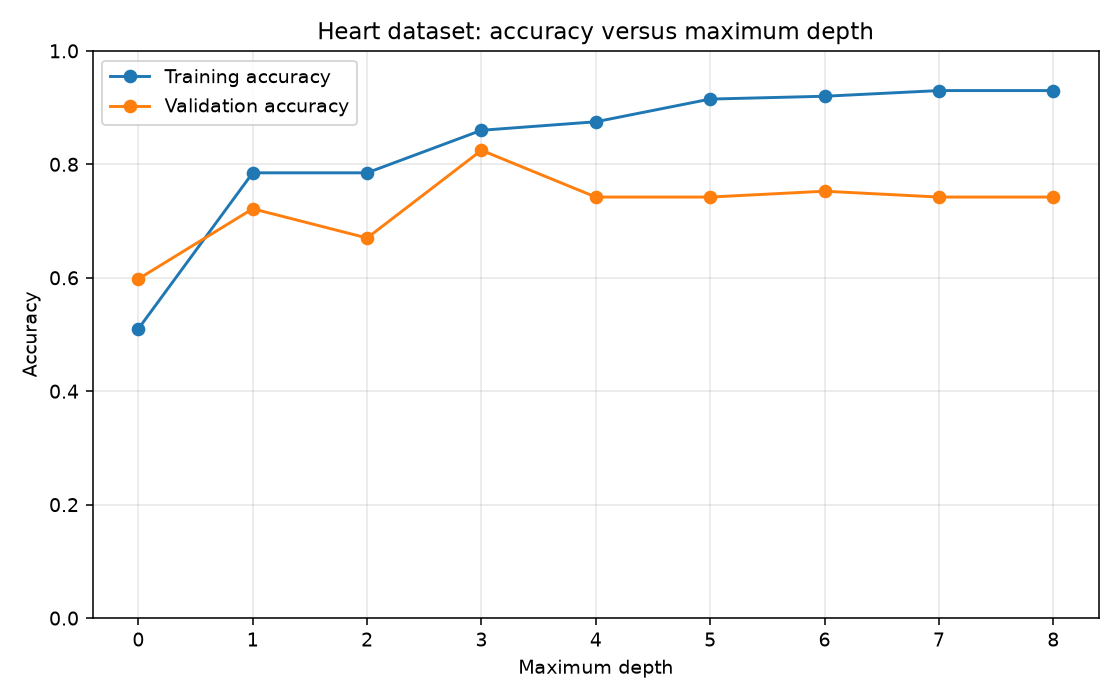

In [29]:
import matplotlib.pyplot as plt

# Give each column a name that describes its role in the plot.
maximum_depths = depth_results["Maximum depth"]
training_accuracies = depth_results["Training accuracy"]
validation_accuracies = depth_results["Validation accuracy"]

# The figure is the full image; the axes are the area containing the curves.
figure, axes = plt.subplots(figsize=(8, 5))
axes.plot(maximum_depths, training_accuracies, marker="o", label="Training accuracy")
axes.plot(maximum_depths, validation_accuracies, marker="o", label="Validation accuracy")

axes.set_xlabel("Maximum depth")
axes.set_ylabel("Accuracy")
axes.set_title("Heart dataset: accuracy versus maximum depth")
axes.set_xticks(range(9))
axes.set_ylim(0, 1)
axes.grid(alpha=0.3)
axes.legend()
figure.tight_layout()
plt.show()


### Find the best depth and check monotonicity

Here, monotonically increasing means **nondecreasing**: accuracy can stay the same but must never fall. We report every depth tied for the best validation accuracy.


In [30]:
validation_accuracies = depth_results["Validation accuracy"]
best_accuracy = validation_accuracies.max()

# A True/False mask selects every row tied for the best accuracy.
is_best_accuracy = validation_accuracies == best_accuracy
best_depth_rows = depth_results[is_best_accuracy]
best_depths = best_depth_rows["Maximum depth"].tolist()

training_accuracies = depth_results["Training accuracy"]
training_never_decreases = training_accuracies.is_monotonic_increasing
validation_never_decreases = validation_accuracies.is_monotonic_increasing

print("Training accuracy is nondecreasing:", training_never_decreases)
print("Validation accuracy is nondecreasing:", validation_never_decreases)
print(f"Best validation accuracy: {best_accuracy:.2%}")
print("Depths achieving it:", best_depths)


Training accuracy is nondecreasing: True
Validation accuracy is nondecreasing: False
Best validation accuracy: 82.47%
Depths achieving it: [3]


### Answer

Validation accuracy is **not monotonically increasing**: it falls at some greater depths. Training accuracy **is nondecreasing**, with some plateaus.

The highest validation accuracy is **82.47%**, achieved at maximum depth **3**.

Increasing depth allows the tree to fit training examples more closely, but those extra splits do not always help on validation examples. The growing gap between training and validation accuracy illustrates overfitting.

Next, Question 5 explores a different stopping rule: the minimum number of training examples a node must contain before it can split.


## Section 4.3 — Question 5: Minimum splitting size

A node with **fewer than M training examples** cannot split. A node with exactly M examples may still split if the other stopping rules allow it. This restriction applies to the node being split, not to the sizes of its resulting children.

Step 7 includes `min_size=0` in the `build_tree()` function, passes it to both recursive calls, and uses this stopping rule:

```python
if len(data) < min_size:
    return node
```

The default of 0 leaves our earlier results unchanged. Running this notebook from top to bottom defines the function before this experiment.

We test every integer minimum size from 0 through the 200 training examples, inclusive. For this experiment, there is no depth limit, the information gain threshold is 0, and we do not prune the trees.


In [31]:
validation_features = heart_val.iloc[:, :-1]
validation_labels = heart_val.iloc[:, -1]
number_of_training_examples = len(heart_train)

size_records = []
# Add 1 because range excludes its upper endpoint: we want to include 200.
for minimum_size in range(number_of_training_examples + 1):
    tree = build_tree(
        data=heart_train,
        max_depth=None,
        threshold=0.0,
        min_size=minimum_size,
    )
    predictions = predict(tree, validation_features)
    validation_error = error_rate(validation_labels, predictions)

    size_record = {
        "Minimum splitting size": minimum_size,
        "Validation accuracy": 1 - validation_error,
    }
    size_records.append(size_record)

size_results = pd.DataFrame(size_records)

# First find the best accuracy, then collect all sizes that achieved it.
validation_accuracies = size_results["Validation accuracy"]
best_size_accuracy = validation_accuracies.max()
is_best_accuracy = validation_accuracies == best_size_accuracy
best_size_rows = size_results[is_best_accuracy]
best_sizes = best_size_rows["Minimum splitting size"]

# The assignment asks for the smallest size among ties.
best_min_size = int(best_sizes.min())

print("Optimal minimum splitting size:", best_min_size)
print(f"Validation accuracy: {best_size_accuracy:.2%}")
print("All sizes tied for best accuracy:", best_sizes.tolist())


Optimal minimum splitting size: 22
Validation accuracy: 82.47%
All sizes tied for best accuracy: [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]


### Answer

The optimal minimum splitting size is **22**, with validation accuracy **82.47%**. This is the smallest size among those tied for the highest accuracy, as required.

Next, Question 6 varies the information gain threshold from 0.00 to 1.00 in steps of 0.01.


## Section 4.3 — Question 6: Information gain threshold

Test thresholds from **0.00 through 1.00 in steps of 0.01** on the heart dataset. At each node, the best information gain must be **strictly greater** than the threshold to permit a split, following Section 4.2.

We keep `max_depth=None` and `min_size=0` and do not prune, so this experiment varies only the information gain threshold. Dividing integers from 0 through 100 by 100 gives the 101 requested threshold values.

If several thresholds achieve the best validation accuracy, report the smallest.


In [32]:
validation_features = heart_val.iloc[:, :-1]
validation_labels = heart_val.iloc[:, -1]

threshold_records = []
for step in range(101):
    information_gain_threshold = step / 100  # 0.00, 0.01, ..., 1.00.
    tree = build_tree(
        data=heart_train,
        max_depth=None,
        threshold=information_gain_threshold,
        min_size=0,
    )
    predictions = predict(tree, validation_features)
    validation_error = error_rate(validation_labels, predictions)

    threshold_record = {
        "Information gain threshold": information_gain_threshold,
        "Validation accuracy": 1 - validation_error,
    }
    threshold_records.append(threshold_record)

threshold_results = pd.DataFrame(threshold_records)

# Use the same selection steps as the minimum-size experiment.
validation_accuracies = threshold_results["Validation accuracy"]
best_threshold_accuracy = validation_accuracies.max()
is_best_accuracy = validation_accuracies == best_threshold_accuracy
best_threshold_rows = threshold_results[is_best_accuracy]
best_thresholds = best_threshold_rows["Information gain threshold"]
best_threshold = best_thresholds.min()

print(f"Optimal information gain threshold: {best_threshold:.2f}")
print(f"Validation accuracy: {best_threshold_accuracy:.2%}")
print("All thresholds tied for best accuracy:", best_thresholds.tolist())


Optimal information gain threshold: 0.04
Validation accuracy: 75.26%
All thresholds tied for best accuracy: [0.04, 0.05, 0.06, 0.07]


### Answer

The optimal information gain threshold is **0.04**, with validation accuracy **75.26%**. This is the smallest threshold among those tied for the highest accuracy.

All six empirical questions now have answers in this notebook. Section 4.4 also requires a self-contained `decision_tree.py` for submission; preparing that file is the next step.
